# Random Forest

## Aim
This notebook implements a Random Forest classifier to predict `severity_label` from a combination of article text and structured features.  The workflow follows the required individual technique checklist, including preprocessing, baseline comparison, hyperparameter tuning with stratified cross validation, evaluation using multiple metrics and visualisations, interpretation, limitations and ethical considerations, and a reference list.

## Technique overview and suitability
Random Forest is an ensemble method that trains many decision trees on bootstrapped samples of the training data and, at each split, considers only a random subset of features.  Classification predictions are made by majority voting across trees.  This design reduces variance compared with a single tree and usually improves generalisation on noisy data (Breiman, 2001) [1].

This technique fits the project because the prediction task is multi class classification and the dataset contains mixed predictors.  After converting the `content` field into TF IDF features, the model can combine sparse text signals with numeric and binary variables in one pipeline without requiring feature scaling.  Random Forest also provides an interpretable starting point through feature importance outputs, which can support qualitative analysis, even if those importance scores must be interpreted cautiously.

**Strengths:** strong baseline for mixed tabular features, captures non linear effects and interactions, robust to noise, less prone to overfitting than a single decision tree (Breiman, 2001) [1].  
**Weaknesses:** can be computationally heavy with high dimensional sparse text, may rely on shallow keyword cues rather than semantics, and impurity based feature importances may be biased, especially when predictors are correlated or have many possible split points (Strobl et al., 2007) [2].  To manage this, TF IDF dimensionality is capped and the tuned model is assessed with stratified cross validation rather than a single split only.

## Background and Related work
Random Forest is widely used as a competitive baseline for classification on structured data because bagging and random feature selection reduce variance and typically improve out of sample performance (Breiman, 2001) [1].  In text classification, a common and efficient representation is TF IDF, which transforms each document into a sparse vector of weighted terms and short phrases, emphasising terms that are frequent within a document but less common across the corpus (Ramos, 2003) [3].  This representation is a standard baseline because it is simple, scalable, and often competitive for topic and label prediction tasks.

However, combining TF IDF with tree ensembles introduces practical trade offs.  Sparse high dimensional vectors can increase training time and memory usage, and they can make interpretation less stable because many correlated n grams may encode similar meaning.  In this notebook, TF IDF is therefore capped to a fixed maximum number of features and model selection is performed with stratified cross validation to reduce sensitivity to a single train test split.

Finally, `severity_label` is imbalanced, so accuracy alone can give an overly optimistic view if performance is driven by the majority class.  Macro averaged F1 is reported because it weights each class equally, making minority class performance visible and aligning evaluation with the project requirement to assess multi class behaviour rather than only overall correctness (Sokolova and Lapalme, 2009) [4].

In [ ]:
import numpy as np
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer #Vecctorising Text
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [66]:
# Make results repeatable and document the software environment used

RANDOM_STATE = 42
TEST_SIZE = 0.20

# Print versions so results can be reproduced and reported in the notebook or report
print("Python version:", sys.version.split()[0])

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)

# Print the key constants used later in the notebook for transparency.
print("RANDOM_STATE:", RANDOM_STATE)
print("TEST_SIZE:", TEST_SIZE)

Python version: 3.13.2
numpy: 2.4.1
pandas: 2.3.3
scikit-learn: 1.8.0
matplotlib: 3.10.8
RANDOM_STATE: 42
TEST_SIZE: 0.2


## Data, target, and modelling choice

The supervised task is multi class classification where the target variable is `severity_label`.  All other columns are treated as candidate predictors, including tag columns, while excluding any raw numeric severity value that would directly leak the answer.  The `content` column provides the text signal and is transformed into TF IDF features.  Stratified splitting is used so the severity distribution is similar in training and testing.  Macro F1 is reported alongside accuracy because the class distribution is imbalanced.

Loaded: Datasets/Finalized_Dataset.csv
Dataset shape (rows, cols): (432, 16)

Tag columns found (kept as features):
['tag_National', 'tag_Accident', 'tag_Traffic', 'tag_Police', 'tag_Transport']

Target value counts:
severity_label
3    194
4     89
2     71
1     44
0     34
Name: count, dtype: int64


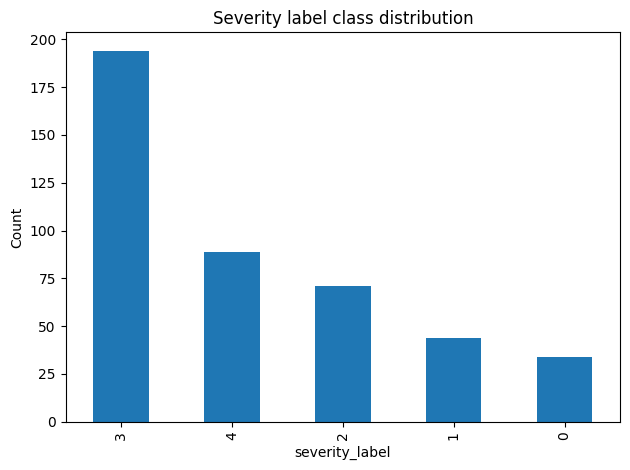


Missing values proportion (top 10 columns):
content                      0.0
temperature_2m_mean          0.0
apparent_temperature_mean    0.0
precipitation_sum            0.0
precipitation_hours          0.0
wind_speed_10m_max           0.0
is_holiday                   0.0
month                        0.0
tag_National                 0.0
tag_Accident                 0.0
dtype: float64

Prepared X shape: (432, 15)
Prepared y shape: (432,)

TF IDF settings (will be fitted later inside the pipeline):
{'max_features': 1000, 'ngram_range': (1, 2), 'stop_words': 'english', 'min_df': 3, 'max_df': 0.8}

Preprocessing pipeline ready.
Text column: content
Number of non text feature columns: 14


In [67]:
# predict severity_label, include tag_ columns as features, exclude any severity numeric 

DATA_PATHS = [
    "Finalized_Dataset.csv",
    "Datasets/Finalized_Dataset.csv",
    "/mnt/data/Finalized_Dataset.csv",
]

data_path = next((p for p in DATA_PATHS if os.path.exists(p)), None)
if data_path is None:
    raise FileNotFoundError(
        "Finalized_Dataset.csv not found.  Update DATA_PATHS to match your folder structure."
    )

df = pd.read_csv(data_path)

print("Loaded:", data_path)
print("Dataset shape (rows, cols):", df.shape)

# Define target and validate required columns

TEXT_COL = "content"
TARGET_COL = "severity_label"
TAG_PREFIX = "tag_"

if TEXT_COL not in df.columns:
    raise ValueError("Expected a text column named 'content'.")
if TARGET_COL not in df.columns:
    raise ValueError("Expected target column 'severity_label' in Finalized_Dataset.csv.")

# Tag columns are kept as features (team decision)
tag_cols = [c for c in df.columns if c.startswith(TAG_PREFIX)]
print("\nTag columns found (kept as features):")
print(tag_cols)

# Target
y = df[TARGET_COL].astype(str).copy()  # keep labels consistent even if stored as ints
print("\nTarget value counts:")
print(y.value_counts(dropna=False))

# Visualise target distribution (helps justify stratification and macro metrics later)
y.value_counts().plot(kind="bar")
plt.title("Severity label class distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Build X, basic checks, and cleanup

# Start X as everything except the target label
X = df.drop(columns=[TARGET_COL]).copy()

# If a numeric severity column exists, exclude it to prevent label leakage
# The exact name can vary, so we defensively check common possibilities.
POTENTIAL_SEVERITY_NUM_COLS = ["severity", "severity_score", "severity_level", "severity_num"]
drop_severity_num = [c for c in POTENTIAL_SEVERITY_NUM_COLS if c in X.columns]
if drop_severity_num:
    print("\nDropping potential numeric severity column(s) to avoid leakage:", drop_severity_num)
    X = X.drop(columns=drop_severity_num)

# Missingness overview (should be low or zero in the final dataset)
print("\nMissing values proportion (top 10 columns):")
missing_prop = df.isna().mean().sort_values(ascending=False)
print(missing_prop.head(10).round(4))

# Make text safe for vectorisation
X[TEXT_COL] = X[TEXT_COL].fillna("")

# Drop constant feature columns (no predictive value, cleaner feature importance later)
constant_cols = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
if constant_cols:
    print("\nDropping constant feature columns:", constant_cols)
    X = X.drop(columns=constant_cols)

print("\nPrepared X shape:", X.shape)
print("Prepared y shape:", y.shape)

#  Preprocessing pipeline setup (TF IDF + passthrough for all non text features)

# All non text columns will be treated as numeric or already encoded features
# This includes weather, calendar variables, and tag_ columns.
NUM_COLS = [c for c in X.columns if c != TEXT_COL]

# TF IDF settings copied from the team starter code
TFIDF_KWARGS = {
    "max_features": 1000,
    "ngram_range": (1, 2),
    "stop_words": "english",
    "min_df": 3,
    "max_df": 0.8,
}

tfidf = TfidfVectorizer(**TFIDF_KWARGS)

preprocess = ColumnTransformer(
    transformers=[
        ("text", tfidf, TEXT_COL),
        ("num", "passthrough", NUM_COLS),
    ],
    remainder="drop",
)

print("\nTF IDF settings (will be fitted later inside the pipeline):")
print(TFIDF_KWARGS)

print("\nPreprocessing pipeline ready.")
print("Text column:", TEXT_COL)
print("Number of non text feature columns:", len(NUM_COLS))

## Baselines and evaluation plan

Three baselines are reported to make improvements interpretable.  A majority class baseline provides a trivial reference.  A Random Forest baseline using only non text features tests how much signal exists in structured predictors alone.  The main Random Forest model uses TF IDF text plus the same non text features.  Macro F1 is prioritised because it weights each severity class equally and therefore reflects minority class performance.

In [68]:
# Model training

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

# majority class baseline for context: accuracy we would get by always predicting the most common class
majority_class = y_train.value_counts().idxmax()
majority_acc = (y_test == majority_class).mean()
print("\nMajority class:", majority_class)
print("Majority class baseline accuracy:", round(float(majority_acc), 4))

# Baseline preprocessing: non text only
baseline_preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", NUM_COLS),
    ],
    remainder="drop"
)

# Define models
baseline_pipe = Pipeline(
    steps=[
        ("preprocess", baseline_preprocess),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )),
    ]
)

main_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),  # TF IDF text + passthrough non text features
        ("rf", RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )),
    ]
)

# Train both models
baseline_pipe.fit(X_train, y_train)
main_pipe.fit(X_train, y_train)

# Evaluate both models
def evaluate_model(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        # Macro F1 weights each class equally, useful when classes are imbalanced
        "Macro F1": f1_score(y_eval, y_pred, average="macro"),
        # Weighted F1 weights classes by support, useful as a complementary metric
        "Weighted F1": f1_score(y_eval, y_pred, average="weighted"),
    }

results = [
    # majority baseline row for the table to have a clear reference point
    {
        "Model": "Majority class baseline",
        "Accuracy": float(majority_acc),
        "Macro F1": f1_score(y_test, np.full_like(y_test, majority_class), average="macro"),
        "Weighted F1": f1_score(y_test, np.full_like(y_test, majority_class), average="weighted"),
    },
    evaluate_model("Baseline  non text only", baseline_pipe, X_test, y_test),
    evaluate_model("Main  text plus non text", main_pipe, X_test, y_test),
]

results_df = pd.DataFrame(results)
results_df[["Accuracy", "Macro F1", "Weighted F1"]] = results_df[["Accuracy", "Macro F1", "Weighted F1"]].round(4)

print("\nModel comparison on held out test set:")
print(results_df)

print("\nClassification report  Main model:")
print(classification_report(y_test, main_pipe.predict(X_test)))

Train shape: (345, 15)  Test shape: (87, 15)

Train target distribution:
severity_label
3    0.449
4    0.206
2    0.165
1    0.101
0    0.078
Name: proportion, dtype: float64

Test target distribution:
severity_label
3    0.448
4    0.207
2    0.161
1    0.103
0    0.080
Name: proportion, dtype: float64

Majority class: 3
Majority class baseline accuracy: 0.4483

Model comparison on held out test set:
                      Model  Accuracy  Macro F1  Weighted F1
0   Majority class baseline    0.4483    0.1238       0.2775
1   Baseline  non text only    0.4713    0.3934       0.4539
2  Main  text plus non text    0.7586    0.6766       0.7317

Classification report  Main model:
              precision    recall  f1-score   support

           0       0.70      1.00      0.82         7
           1       0.62      0.56      0.59         9
           2       0.60      0.21      0.32        14
           3       0.85      0.90      0.88        39
           4       0.70      0.89      0.78

## Interpretation of baseline comparison

The train and test splits preserve the same severity distribution, with severity 3 as the majority class at about 0.45 of the data, followed by severity 4 at about 0.21, then severity 2 at about 0.16, and the rarer classes severity 1 and 0 at about 0.10 and 0.08.  This imbalance means accuracy alone can look acceptable even if the model underperforms on minority classes, so Macro F1 is the more informative summary metric here.

The majority class baseline reaches 0.448 accuracy by always predicting severity 3, but its Macro F1 is only 0.124, showing that it fails to capture the other classes.  The Random Forest trained on non text structured features improves only slightly, reaching 0.471 accuracy and Macro F1 of 0.393, suggesting limited separability from weather, calendar, and tag features alone.  Adding TF IDF text features produces a large gain, with accuracy rising to 0.759 and Macro F1 to 0.677, indicating that the article content contains strong signals for severity.

The classification report for the main model shows strong performance for the frequent classes, especially severity 3 with high precision and recall and severity 4 with high recall, while severity 2 is notably weaker with low recall.  This pattern is consistent with both class imbalance and overlapping language between mid severity incidents, where similar terms may describe events that differ mainly in consequences rather than distinct keywords.  Overall, text features are the primary driver of performance, with structured features providing secondary context.

## Hyperparameter tuning

This section tunes key Random Forest hyperparameters using stratified cross validation.  Macro F1 is used as the primary score because class imbalance means accuracy can overstate performance on the majority class.

In [69]:
# Define a fresh pipeline for tuning (text plus non text)
tune_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("rf", RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=1
        )),
    ]
)

# Stratified CV keeps severity distribution similar in each fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Search space
param_distributions = {
    "rf__n_estimators": [200, 300, 500, 700],
    "rf__max_depth": [None, 10, 20, 30, 50],
    "rf__min_samples_split": [2, 5, 10,20],
    "rf__min_samples_leaf": [1, 2, 4, 8],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "rf__class_weight": ["balanced",None],
    "preprocess__text__max_features": [500, 1000, 2000, 3000],
}

search = RandomizedSearchCV(
    estimator=tune_pipe,
    param_distributions=param_distributions,
    n_iter=80,
    scoring="f1_macro",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
    refit=True,
    return_train_score=True
)

print("Starting hyperparameter tuning with stratified cross validation...")
search.fit(X_train, y_train)

print("\nBest cross validation Macro F1:", round(float(search.best_score_), 4))
print("\nBest parameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

best_model = search.best_estimator_

# Evaluate tuned model on the held out test set
y_pred = best_model.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
test_macro_f1 = f1_score(y_test, y_pred, average="macro")
test_weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("\nTuned model performance on held out test set:")
print("Accuracy:", round(float(test_acc), 4))
print("Macro F1:", round(float(test_macro_f1), 4))
print("Weighted F1:", round(float(test_weighted_f1), 4))

print("\nClassification report  Tuned model:")
print(classification_report(y_test, y_pred))

# inspecting the top CV results
cv_results = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
cols_to_show = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score",
    "params"
]
print("\nTop 10 hyperparameter settings by mean CV Macro F1:")
print(cv_results[cols_to_show].head(10))

Starting hyperparameter tuning with stratified cross validation...
Fitting 5 folds for each of 80 candidates, totalling 400 fits

Best cross validation Macro F1: 0.7713

Best parameters:
  rf__n_estimators: 700
  rf__min_samples_split: 2
  rf__min_samples_leaf: 1
  rf__max_features: 0.5
  rf__max_depth: 30
  rf__class_weight: balanced
  preprocess__text__max_features: 2000

Tuned model performance on held out test set:
Accuracy: 0.8621
Macro F1: 0.8594
Weighted F1: 0.8627

Classification report  Tuned model:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       0.75      1.00      0.86         9
           2       0.71      0.71      0.71        14
           3       0.89      0.87      0.88        39
           4       1.00      0.83      0.91        18

    accuracy                           0.86        87
   macro avg       0.85      0.88      0.86        87
weighted avg       0.87      0.86      0.86        8

## Tuning summary and reliability notes

The tuned Random Forest improves performance substantially compared with the untuned model, particularly in Macro F1, which indicates better balance across severity classes rather than gains driven only by the majority class.  The best configuration uses class weighting and a larger TF IDF vocabulary, suggesting that addressing imbalance and capturing more text information are important for this task.

Some candidate settings achieve near perfect training scores during cross validation, which can indicate a tendency to overfit, especially with high dimensional sparse text features.  For this reason, the cross validation Macro F1 is treated as the more conservative estimate of generalisation, and results are also verified on the held out test set.  The remaining weaker performance on severity 2 is consistent with overlap in language between adjacent severity levels and the fact that this class sits between common categories.

In [70]:
# Save best parameters for reuse in later evaluation and visualisation cells
best_params = search.best_params_
print("\nSaved best_params for later cells.")

# Also keep a fitted reference to the tuned pipeline for later plots
tuned_pipe = best_model
print("Saved tuned_pipe for later cells.")


Saved best_params for later cells.
Saved tuned_pipe for later cells.


## Evaluation and visualisations

This section reports multiple metrics and visualisations for the tuned model, including a confusion matrix, per class F1, and feature importance to support interpretation.


Tuned test accuracy: 0.8621
Tuned test Macro F1: 0.8594


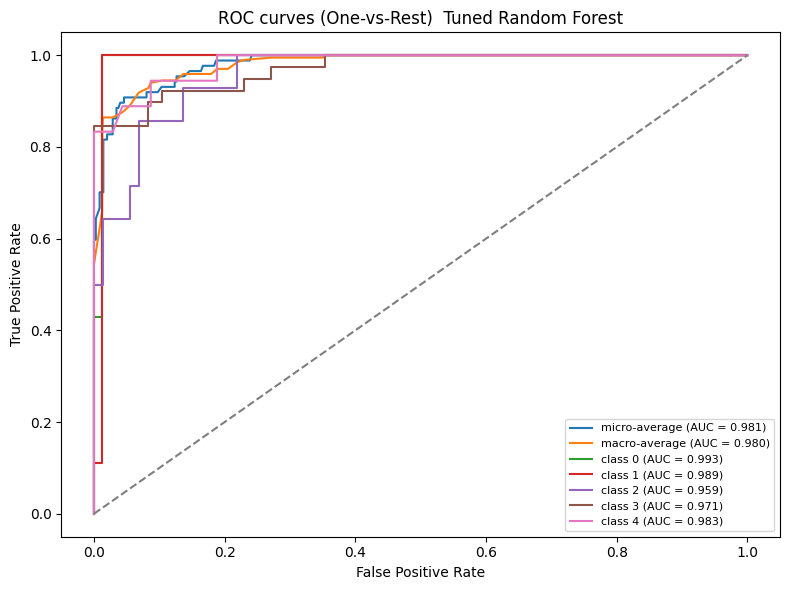


ROC AUC summary (OvR):
Class  ROC AUC
    0   0.9929
    1   0.9886
    2   0.9589
    3   0.9712
    4   0.9827
micro   0.9814
macro   0.9804


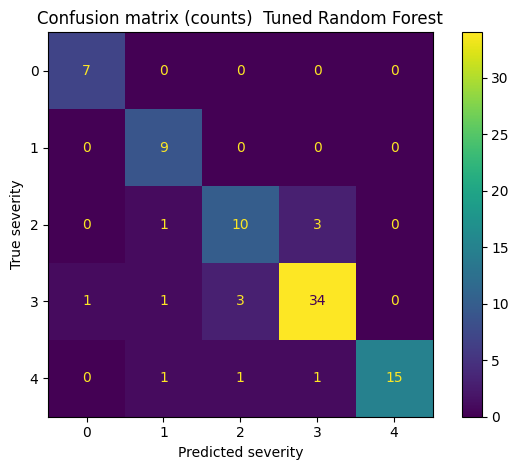

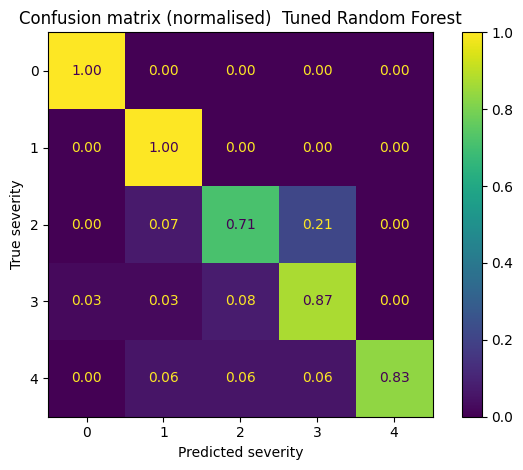


Per class metrics  Tuned model:
Class  Precision  Recall     F1  Support
    0     0.8750  1.0000 0.9333        7
    1     0.7500  1.0000 0.8571        9
    2     0.7143  0.7143 0.7143       14
    3     0.8947  0.8718 0.8831       39
    4     1.0000  0.8333 0.9091       18


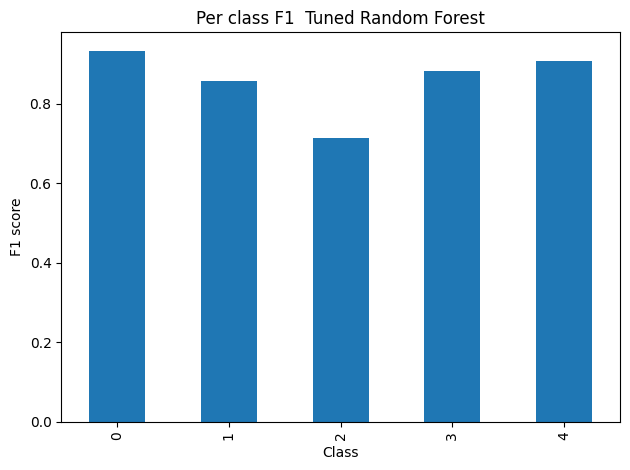

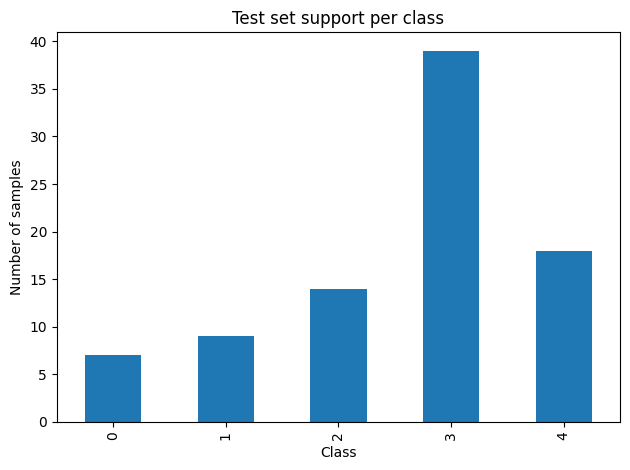

In [71]:
# Confusion matrix, ROC curves, and per class plots for the tuned model

if "tuned_pipe" not in globals():
    raise NameError("tuned_pipe not found.  Run Cell 12 tuning first so tuned_pipe is available.")

# Predict on held out test set
y_pred = tuned_pipe.predict(X_test)

print("Tuned test accuracy:", round(float(accuracy_score(y_test, y_pred)), 4))
print("Tuned test Macro F1:", round(float(f1_score(y_test, y_pred, average="macro")), 4))

# Class labels
classes = sorted(y.unique())

# ROC curves (multiclass One-vs-Rest)
# ROC requires probability scores.  For multiclass, we binarise y_test and compute OvR curves.

# Predict probabilities (columns correspond to the classifier's internal class order)
y_proba = tuned_pipe.predict_proba(X_test)

# Align classes to the classifier's internal ordering to avoid mismatched curves
clf_classes = tuned_pipe.named_steps["rf"].classes_
classes = list(clf_classes)

# Binarise true labels for OvR ROC
y_test_bin = label_binarize(y_test, classes=classes)

fpr = {}
tpr = {}
roc_auc = {}

for i, c in enumerate(classes):
    fpr[c], tpr[c], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[c] = auc(fpr[c], tpr[c])

# Micro average
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro average
all_fpr = np.unique(np.concatenate([fpr[c] for c in classes]))
mean_tpr = np.zeros_like(all_fpr)

for c in classes:
    mean_tpr += np.interp(all_fpr, fpr[c], tpr[c])

mean_tpr /= len(classes)

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(8, 6))

# Micro and macro first
plt.plot(fpr["micro"], tpr["micro"], label=f"micro-average (AUC = {roc_auc['micro']:.3f})")
plt.plot(fpr["macro"], tpr["macro"], label=f"macro-average (AUC = {roc_auc['macro']:.3f})")

# Each class
for c in classes:
    plt.plot(fpr[c], tpr[c], label=f"class {c} (AUC = {roc_auc[c]:.3f})")

# Chance line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC curves (One-vs-Rest)  Tuned Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

auc_df = pd.DataFrame(
    {
        "Class": [str(c) for c in classes] + ["micro", "macro"],
        "ROC AUC": [roc_auc[c] for c in classes] + [roc_auc["micro"], roc_auc["macro"]],
    }
)
auc_df["ROC AUC"] = auc_df["ROC AUC"].round(4)

print("\nROC AUC summary (OvR):")
print(auc_df.to_string(index=False))

# Confusion matrices

cm = confusion_matrix(y_test, y_pred, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(values_format="d")
plt.title("Confusion matrix (counts)  Tuned Random Forest")
plt.xlabel("Predicted severity")
plt.ylabel("True severity")
plt.tight_layout()
plt.show()

# Confusion matrix  normalised by true class
cm_norm = confusion_matrix(y_test, y_pred, labels=classes, normalize="true")
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=classes)
disp_norm.plot(values_format=".2f")
plt.title("Confusion matrix (normalised)  Tuned Random Forest")
plt.xlabel("Predicted severity")
plt.ylabel("True severity")
plt.tight_layout()
plt.show()


# Per class precision, recall, F1, support + plots

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=classes, zero_division=0
)

per_class_df = pd.DataFrame(
    {
        "Class": classes,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Support": support,
    }
)

per_class_df[["Precision", "Recall", "F1"]] = per_class_df[["Precision", "Recall", "F1"]].round(4)

print("\nPer class metrics  Tuned model:")
print(per_class_df.to_string(index=False))

# Per class F1 bar plot
per_class_df.set_index("Class")["F1"].plot(kind="bar")
plt.title("Per class F1  Tuned Random Forest")
plt.ylabel("F1 score")
plt.tight_layout()
plt.show()

# Support bar plot
per_class_df.set_index("Class")["Support"].plot(kind="bar")
plt.title("Test set support per class")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()


Total engineered features: 2014

Top 20 features overall:
                feature  importance
         text__hospital    0.113483
         text__injuries    0.108379
            text__death    0.083900
            text__fatal    0.062346
         text__accident    0.040321
          text__traffic    0.028343
             text__dead    0.022456
         text__grievous    0.017423
         text__year old    0.016672
            text__crash    0.016643
           text__police    0.014653
        text__accidents    0.013705
text__grievous injuries    0.012567
            text__malta    0.012237
      num__tag_Accident    0.010386
          text__injured    0.009144
        text__certified    0.006868
              text__old    0.006807
num__wind_speed_10m_max    0.005923
        text__mater dei    0.005849


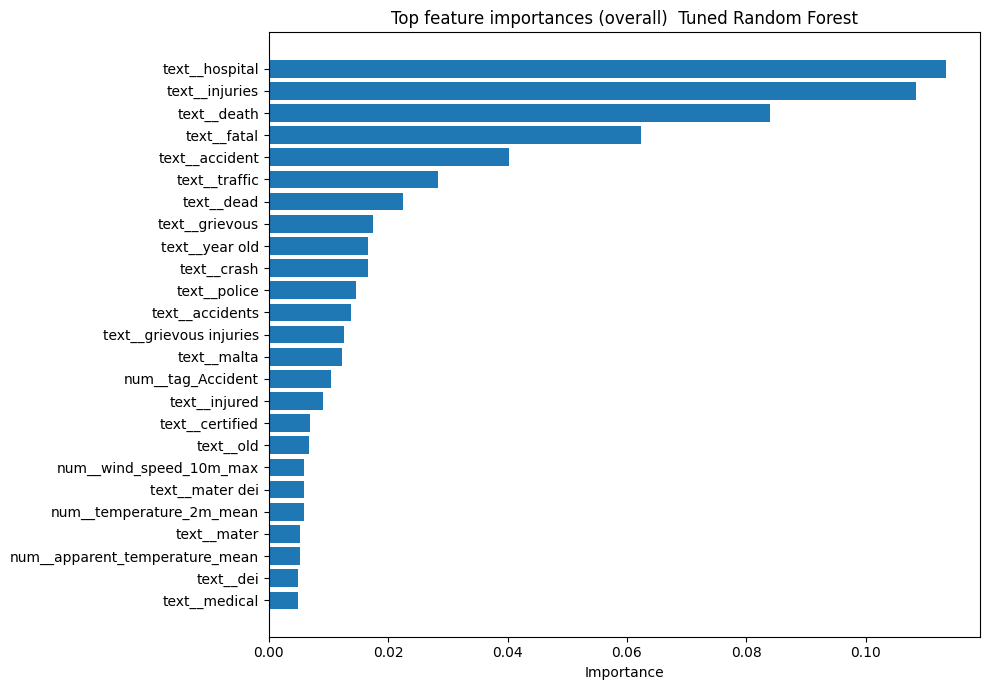


Top 20 text terms:
             term  importance
         hospital    0.113483
         injuries    0.108379
            death    0.083900
            fatal    0.062346
         accident    0.040321
          traffic    0.028343
             dead    0.022456
         grievous    0.017423
         year old    0.016672
            crash    0.016643
           police    0.014653
        accidents    0.013705
grievous injuries    0.012567
            malta    0.012237
          injured    0.009144
        certified    0.006868
              old    0.006807
        mater dei    0.005849
            mater    0.005204
              dei    0.004918

Top numeric features:
                     name   importance
             tag_Accident 1.038593e-02
       wind_speed_10m_max 5.923377e-03
      temperature_2m_mean 5.814180e-03
apparent_temperature_mean 5.155930e-03
                  dow_sin 4.203557e-03
                    month 2.713222e-03
        precipitation_sum 1.132749e-03
               

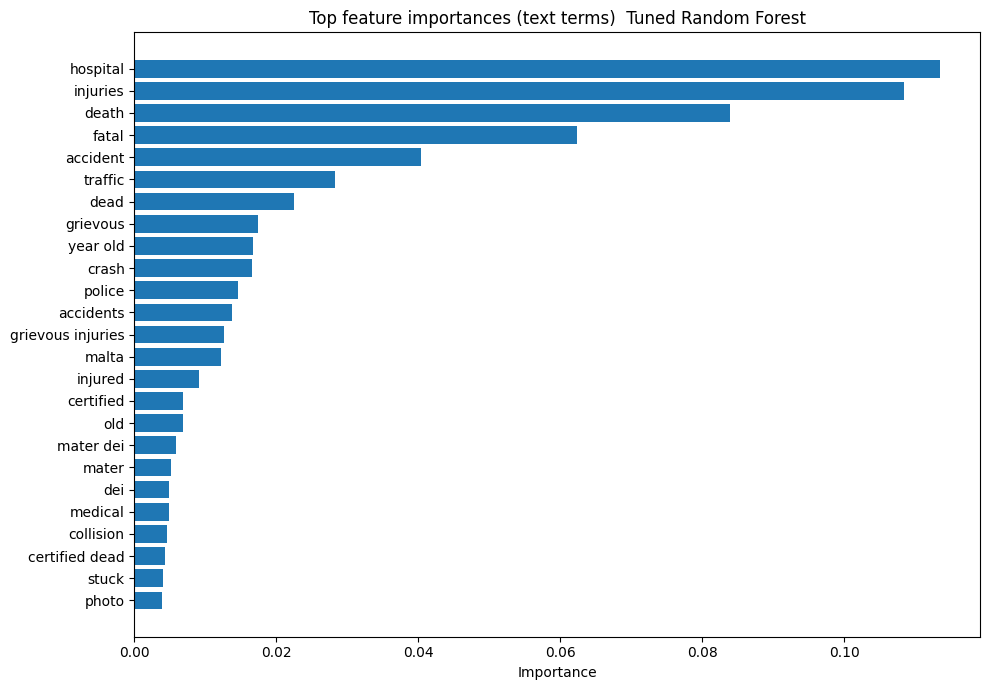

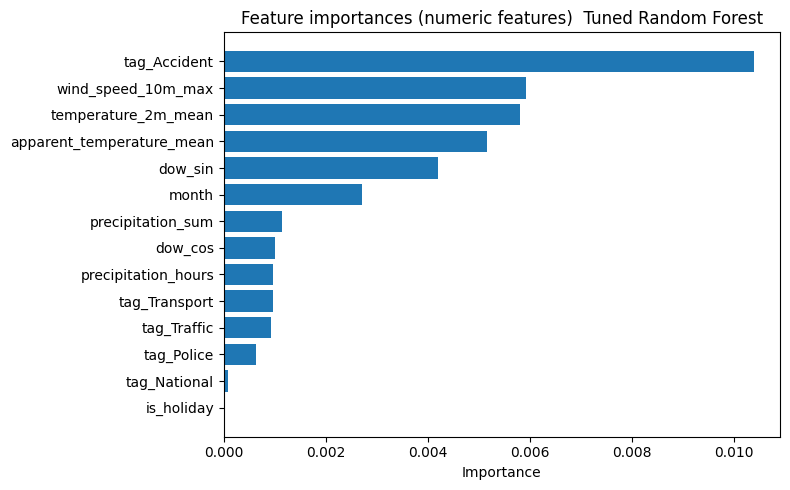

In [72]:
# Feature importance (tuned Random Forest)

# Important note:
# The feature_importances_ values from Random Forest are impurity based.
# They are a helpful first look, but they can be biased when predictors are correlated,
# and they can favour features that offer many possible split points.
# Treat the rankings as indicative rather than as definitive causal drivers.

if "tuned_pipe" not in globals():
    raise NameError("tuned_pipe not found.  Run the tuning cell first so tuned_pipe is available.")

rf = tuned_pipe.named_steps["rf"]
pre = tuned_pipe.named_steps["preprocess"]

# Get feature names produced by the ColumnTransformer
feature_names = pre.get_feature_names_out()

# Random Forest impurity based importances
importances = rf.feature_importances_

fi_df = pd.DataFrame(
    {"feature": feature_names, "importance": importances}
).sort_values("importance", ascending=False)

print(
    "Warning: Random Forest feature_importances_ are impurity based.  "
    "They are useful for quick interpretation, but can be biased with correlated predictors "
    "and can favour features with many split points.  Use these rankings as indicative."
)

print("\nTotal engineered features:", fi_df.shape[0])
print("\nTop 20 features overall:")
print(fi_df.head(20).to_string(index=False))

# Plot top features overall
TOP_K = 25
top_df = fi_df.head(TOP_K).copy().sort_values("importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_df["feature"], top_df["importance"])
plt.title("Top feature importances (overall)  Tuned Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Split into text and numeric importances for clearer interpretation
text_mask = fi_df["feature"].astype(str).str.startswith("text__")
num_mask = fi_df["feature"].astype(str).str.startswith("num__")

text_df = fi_df.loc[text_mask].copy()
num_df = fi_df.loc[num_mask].copy()

# Clean labels for readability
text_df["term"] = text_df["feature"].astype(str).str.replace("text__", "", regex=False)
num_df["name"] = num_df["feature"].astype(str).str.replace("num__", "", regex=False)

print("\nTop 20 text terms:")
print(text_df[["term", "importance"]].head(20).to_string(index=False))

print("\nTop numeric features:")
print(num_df[["name", "importance"]].head(20).to_string(index=False))

# Plot top text terms
TOP_TEXT = 25
top_text = text_df.head(TOP_TEXT).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_text["term"], top_text["importance"])
plt.title("Top feature importances (text terms)  Tuned Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Plot numeric features (usually fewer)
top_num = num_df.sort_values("importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(top_num["name"], top_num["importance"])
plt.title("Feature importances (numeric features)  Tuned Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Interpretation and practical insight

Adding TF IDF text features clearly improves severity prediction compared with using only structured features.  The majority class baseline reaches 0.4483 accuracy, while the non text baseline Random Forest only rises to 0.4713, suggesting limited signal from weather and calendar style variables alone.  Once text is included, performance increases strongly.  The tuned model achieves 0.8621 accuracy and 0.8594 Macro F1, meaning it performs well across classes rather than mainly on the dominant class 3.

The confusion matrix shows that most mistakes occur between neighbouring classes, especially severity 2 being predicted as 3, which is plausible because moderate and higher severity reports can share overlapping language.  Per class results remain strongest for the dominant class 3 and the extremes, while class 2 is still the weakest, consistent with borderline wording.

The ROC curves (one versus rest) support strong separability overall.  The macro average AUC is about 0.98 and the micro average AUC is about 0.98, with each class AUC also very high (roughly 0.96 to 0.99).  These values indicate the model ranks the correct class highly most of the time, although they should be interpreted cautiously because the test set is small and some classes have low support.

Feature importances suggest the model is primarily driven by injury and outcome language.  Terms like hospital, injuries, death, fatal, and grievous dominate the rankings, with structured features like tag_Accident contributing but less strongly.  Practically, this means explicit medical and fatality language is a strong indicator of higher predicted severity, while reports without injury related terms tend to map to lower severity levels.

## Limitations and ethical considerations

A key limitation of this work is class imbalance.  Severity 3 forms the largest share of the dataset, while severity 0 and 1 are comparatively rare.  Although stratified splitting and macro averaged metrics reduce misleading evaluation, the model still learns from fewer minority class examples, making per class results more sensitive to small changes in the test set.  This is one reason macro F1 is reported alongside accuracy.

A second limitation is the risk of proxy leakage.  Even though the severity label itself is excluded from the feature set, some predictors may encode severity indirectly.  In particular, the tag columns could be proxies for severity if they were assigned using similar cues to the severity label, meaning the model may partially learn the labelling process rather than the underlying concept.  This is consistent with tag_Accident appearing among the most influential structured features in the importance ranking.  Temporal and calendar variables may also capture reporting patterns rather than real world severity.

The text pipeline introduces a related limitation: keyword driven learning.  The strongest signals are intuitive terms such as *hospital*, *injuries*, *death*, and *fatal*, but TF IDF is sensitive to phrasing and does not represent deeper context or negation reliably.  For example, “no injuries reported” can share tokens with genuinely severe incidents, which may create brittle behaviour when language shifts or when articles use euphemisms and indirect descriptions.  These are known limitations of bag of words style approaches and linear weighting schemes.  [1], [2]

Generalisability is constrained by dataset size and domain specificity.  Language patterns may reflect a particular news context and reporting style, so performance may drop when applied to different outlets, regions, or time periods.  Before any real world use, the model should be tested on an external dataset and monitored for drift.  [3]

From an ethical and deployment perspective, severity prediction could influence escalation and resource allocation, so errors can have real consequences.  False negatives for high severity cases are particularly risky, and false positives can trigger unnecessary alarm.  A safer deployment is decision support with human review for high severity predictions, transparent confidence reporting, and clear escalation thresholds.  Finally, even if sourced from public reporting, the text may contain sensitive details about individuals or locations, so any use should follow data minimisation and privacy by design principles.  [4]

## References  IEEE style

[1] L. Breiman, “Random forests,” *Machine Learning*, vol. 45, no. 1, pp. 5–32, 2001.

[2] C. D. Manning, P. Raghavan, and H. Schütze, *Introduction to Information Retrieval*.  Cambridge, UK: Cambridge University Press, 2008.

[3] M. Sokolova and G. Lapalme, “A systematic analysis of performance measures for classification tasks,” *Information Processing and Management*, vol. 45, no. 4, pp. 427–437, 2009.

[4] R. Kohavi, “A study of cross validation and bootstrap for accuracy estimation and model selection,” in *Proc. 14th Int. Joint Conf. Artificial Intelligence (IJCAI)*, 1995, pp. 1137–1143.

[5] G. Louppe, L. Wehenkel, A. Sutera, and P. Geurts, “Understanding variable importances in forests of randomized trees,” in *Advances in Neural Information Processing Systems (NeurIPS)*, 2013, pp. 431–439.

[6] F. Pedregosa *et al.*, “Scikit learn: Machine learning in Python,” *Journal of Machine Learning Research*, vol. 12, pp. 2825–2830, 2011.

[7] Scikit learn Developers, *Scikit learn Documentation*, RandomForestClassifier, TfidfVectorizer, ColumnTransformer, Pipeline, RandomizedSearchCV, and classification metrics, accessed Jan. 2026.

[8] C. Strobl, A. L. Boulesteix, A. Zeileis, and T. Hothorn, “Bias in random forest variable importance measures: Illustrations, sources and a solution,” *BMC Bioinformatics*, vol. 8, no. 1, p. 25, 2007, doi: 10.1186/1471-2105-8-25.

## AI Tools Used


ChatGPT and Gemini were used to help draft and refine certain texts and to organise the  overall structure of the notebook.